In [1]:
#!pip install mne

Extracting EDF parameters from C:\BCI\分析实训项目\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\13656\AppData\Local\Temp\ipykernel_9928\386857841.py:16: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot()
C:\Users\13656\anaconda3\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


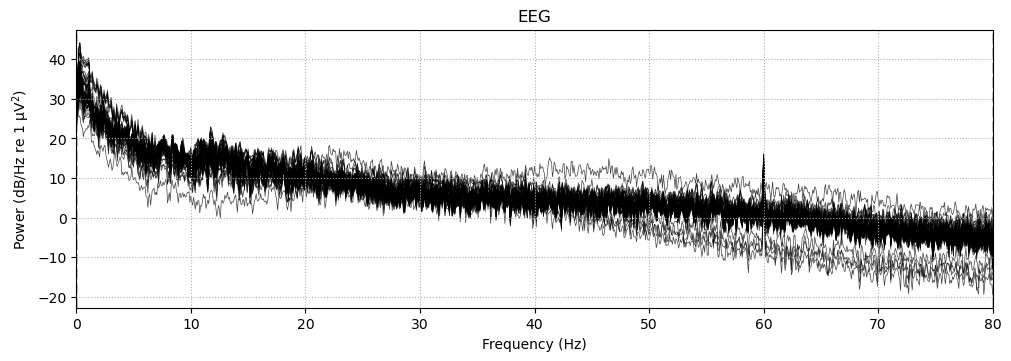

Using matplotlib as 2D backend.


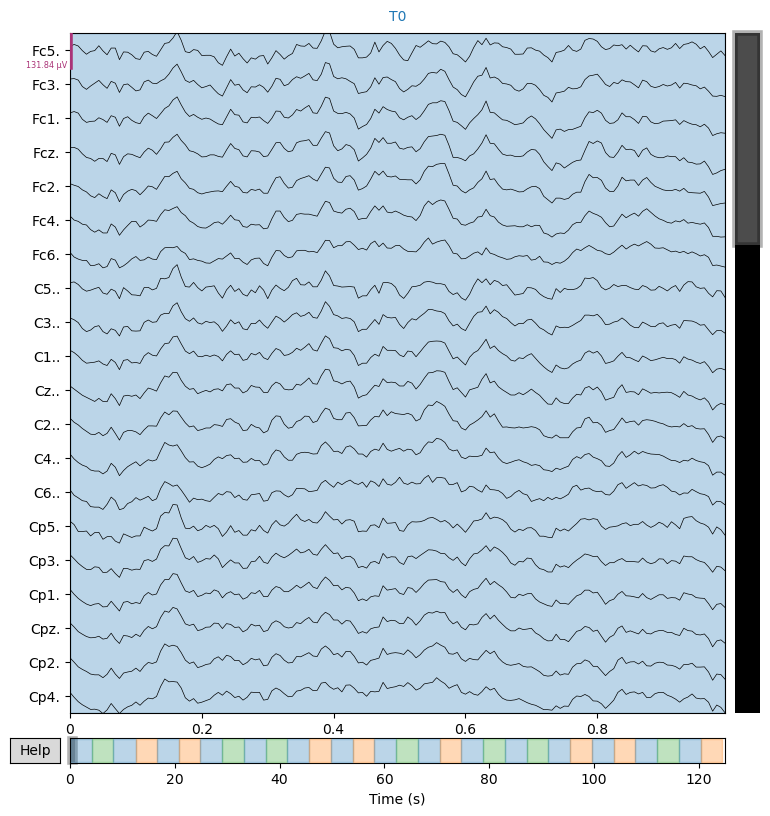

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. 指定文件路径
file_path = "C:/BCI/分析实训项目/eeg-motor-movementimagery-dataset-1.0.0/files/S001/S001R03.edf" 

# 2. 使用MNE读取EDF文件
raw = mne.io.read_raw_edf(file_path, preload=True)

# 3. 打印数据信息
print(raw.info)
# 注意看：采样频率（sfreq）、通道名称（ch_names）、数据长度等

# 4. 绘制原始数据的功率谱密度图，看看频率分布
raw.compute_psd().plot()
plt.show()

# 5. 绘制原始信号的时间序列
raw.plot(duration=1, scalings='auto')
plt.show()

In [3]:
from mne.channels import make_standard_montage

# 获取标准10-20系统电极位置
montage = make_standard_montage('standard_1020')

# 将电极位置应用到数据
raw.set_montage(montage, on_missing='ignore')

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [32]:
print("All channel names in the file:")
print(raw.info['ch_names'])

All channel names in the file:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [ ]:
# 1. 选择通道
eeg_channel_names = ['C3..','Cz..', 'C4..', 'Fz..', 'Pz..']
eeg_picked_channel=raw.pick(eeg_channel_names)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 30.00 Hz: -6.02, -6.02 dB



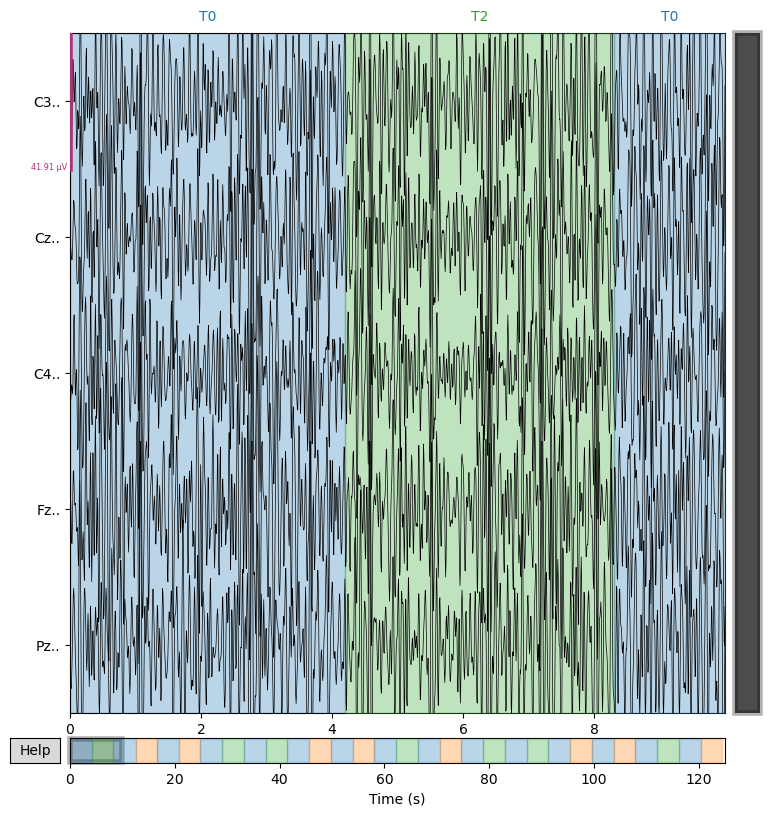

In [ ]:


# 2. 滤波 (Filtering)
# 带通滤波：保留Mu节律（8-13 Hz）和Beta节律（13-30 Hz），它们与运动想象密切相关。
raw_filtered = raw.copy().filter(l_freq=8, h_freq=30, method='iir')

raw_filtered.plot(duration=10, scalings='auto')
plt.show()

In [7]:
file_path = "C:/BCI/分析实训项目/eeg-motor-movementimagery-dataset-1.0.0/files/S001/S001R03.edf"
raw = mne.io.read_raw_edf(file_path, preload=True)

# 查看所有注释（事件标记）
annotations = raw.annotations
print("所有注释描述:", set(annotations.description))
print("注释出现时间:", annotations.onset)

Extracting EDF parameters from C:\BCI\分析实训项目\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
所有注释描述: {'T0', 'T2', 'T1'}
注释出现时间: [  0.    4.2   8.3  12.5  16.6  20.8  24.9  29.1  33.2  37.4  41.5  45.7
  49.8  54.   58.1  62.3  66.4  70.6  74.7  78.9  83.   87.2  91.3  95.5
  99.6 103.8 107.9 112.1 116.2 120.4]


In [8]:
import glob

# 假设所有文件都在一个目录中
files = glob.glob("C:/BCI/分析实训项目/eeg-motor-movementimagery-dataset-1.0.0/files/S001/*.edf")

for file in files:
    raw = mne.io.read_raw_edf(file, preload=False)  # 不加载数据以节省时间
    annotations = raw.annotations
    print(f"文件 {file} 中的事件标记: {set(annotations.description)}")

Extracting EDF parameters from C:\BCI\分析实训项目\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
文件 C:/BCI/分析实训项目/eeg-motor-movementimagery-dataset-1.0.0/files/S001\S001R01.edf 中的事件标记: {'T0'}
Extracting EDF parameters from C:\BCI\分析实训项目\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
文件 C:/BCI/分析实训项目/eeg-motor-movementimagery-dataset-1.0.0/files/S001\S001R02.edf 中的事件标记: {'T0'}
Extracting EDF parameters from C:\BCI\分析实训项目\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
文件 C:/BCI/分析实训项目/eeg-motor-movementimagery-dataset-1.0.0/files/S001\S001R03.edf 中的事件标记: {'T0', 'T2', 'T1'}
Extracting EDF parameters from C:\BCI\分析实训项目\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R04.edf...
EDF file d

['T0' 'T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2' 'T0' 'T2' 'T0' 'T1' 'T0' 'T1'
 'T0' 'T2' 'T0' 'T1' 'T0' 'T2' 'T0' 'T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2'
 'T0' 'T1']
[  0.    4.2   8.3  12.5  16.6  20.8  24.9  29.1  33.2  37.4  41.5  45.7
  49.8  54.   58.1  62.3  66.4  70.6  74.7  78.9  83.   87.2  91.3  95.5
  99.6 103.8 107.9 112.1 116.2 120.4]
Used Annotations descriptions: ['T0', 'T1', 'T2']
Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
1 bad epochs dropped
<Epochs | 29 events (all good), -1 – 3 s (baseline -1 – 0 s), ~737 KiB, data loaded,
 'T0': 14
 'T1': 8
 'T2': 7>


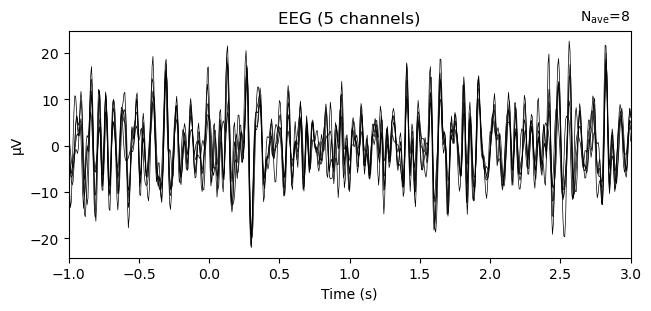

In [ ]:
# 查看原始数据中的注释（事件标记）
annotations = raw_filtered.annotations
print(annotations.description) # 查看发生了什么事件
print(annotations.onset)       # 查看事件发生的时间点

# 根据数据集文档，解码这些事件。
# 例如，'T0' 可能表示休息开始，'T1' 表示左手想象 cue 开始，'T2' 表示右手想象 cue 开始。

# 定义一个事件字典，将注释映射到事件ID
event_id = {'T0': 0, 'T1': 1, 'T2': 2} # 请根据数据集协议修改

# 将注释转换为MNE的事件数组（events array）
events, _ = mne.events_from_annotations(raw_filtered, event_id=event_id)

# 现在围绕这些事件切分数据
tmin, tmax = -1, 3  # 每个epoch将从-1秒到3秒，总共4秒长
epochs = mne.Epochs(raw_filtered, events, event_id, tmin, tmax, baseline=(-1, 0), preload=True)
# baseline参数用于基线校正，这里用cue出现前1秒到0秒作为基线。

# 查看我们得到了多少个 trials
print(epochs)

# 现在，你可以按条件获取数据了
left_trials = epochs['T1']  # 所有左手想象的 trials
right_trials = epochs['T2'] # 所有右手想象的 trials

# 绘制所有 trial 的平均 evoked 响应
left_trials.average().plot()
plt.show()

In [10]:
#conda install scikit-learn

In [11]:
#pip install --upgrade pip setuptools wheel

In [ ]:
# 方法一：经典频带功率特征
from mne.decoding import Vectorizer

# 计算每个通道每个 trial 的平均功率（在Mu/Beta节律内）
# 这里只是一个简单示例，实际特征工程复杂得多
left_data = left_trials.get_data()  # 形状: (n_trials, n_channels, n_times)
right_data = right_trials.get_data()

# 例如，简单地取时间维度上的方差作为特征
features_left = np.var(left_data, axis=2)
features_right = np.var(right_data, axis=2)

# 方法二（更强大）：Common Spatial Patterns (CSP)
# CSP是运动想象分类的金标准特征提取方法。
from mne.decoding import CSP

# 创建标签：0代表左手，1代表右手
labels_left = np.zeros(features_left.shape[0])
labels_right = np.ones(features_right.shape[0])

# 合并数据和标签
X = np.vstack((features_left, features_right))
y = np.hstack((labels_left, labels_right))


In [34]:
from mne.decoding import CSP
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
import numpy as np

# 获取epochs数据和标签
epochs_data = epochs.get_data()  # 形状: (n_epochs, n_channels, n_times)
labels = epochs.events[:, -1]  # 获取事件ID

# 确保标签只有1和2（左手和右手）
# 如果标签是0和1，可能需要调整，但CSP需要整数标签
print("唯一标签:", np.unique(labels))

# 创建CSP变换器，提取4个成分
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# 使用CSP提取特征
csp_features = csp.fit_transform(epochs_data, labels)

# 查看特征形状
print(f"CSP特征形状: {csp_features.shape}")

唯一标签: [0 1 2]
Computing rank from data with rank=None
    Using tolerance 5.7e-06 (2.2e-16 eps * 5 dim * 5.1e+09  max singular value)
    Estimated rank (data): 5
    data: rank 5 computed from 5 data channels with 0 projectors
Reducing data rank from 5 -> 5
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
CSP特征形状: (29, 4)


In [38]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建一个Pipeline：先标准化数据，再用SVM分类
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf'))

# 在训练集上训练
clf.fit(X_train, y_train)

# 在测试集上评估准确率
accuracy = clf.score(X_test, y_test)
print(f"Classification Accuracy: {accuracy:.2f}")

# 或者使用交叉验证更可靠地评估模型
scores = cross_val_score(clf, X, y, cv=5)
print(f"Cross-validation Accuracy: {np.mean(scores):.2f} (+/- {np.std(scores):.2f})")

Classification Accuracy: 0.33
Cross-validation Accuracy: 0.60 (+/- 0.13)


In [40]:
# 使用LDA分类器
clf_lda = make_pipeline(StandardScaler(), LDA())
scores_lda = cross_val_score(clf_lda, csp_features, labels, cv=5, scoring='accuracy')
print(f"LDA准确率: {np.mean(scores_lda):.2f} (+/- {np.std(scores_lda):.2f})")

# 使用SVM分类器（带参数调优）
from sklearn.model_selection import GridSearchCV

# 定义SVM管道
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf'))

# 定义参数网格
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1]
}

# 使用网格搜索和交叉验证
grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(csp_features, labels)

print(f"最佳SVM参数: {grid_search.best_params_}")
print(f"最佳SVM准确率: {grid_search.best_score_:.2f}")

LDA准确率: 0.42 (+/- 0.15)
最佳SVM参数: {'svc__C': 100, 'svc__gamma': 0.001}
最佳SVM准确率: 0.56
